In [7]:
import numpy as np
import rebound
import celmech as cm
from celmech import Poincare, PoincareHamiltonian
from scipy import signal
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [8]:
#helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def get_freq_of_peri(alpha,n_jup,n_sat):
    laplace_coeff_1 = np.pi**(-1)*quad(lambda x: np.cos(x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]
    laplace_coeff_2 = np.pi**(-1)*quad(lambda x: np.cos(2*x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]

    A_11 = n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_1
    A_22 = n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_1
    A_12 = -n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_2
    A_21 = -n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_2

    sols = np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21])
    g_1 = sols[0]
    g_2 = sols[1]

    print(np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21]))
    return g_1,g_2  

[3.55301323e-05 3.82544932e-06]
0.0


/home/miaed/miniconda3/envs/jupyter-env/lib/python3.13/site-packages/scipy/integrate/_ode.py:438: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


12568.88439123742
25137.76878247484
37706.65317371226
50275.53756494968
62844.4219561871
75413.30634742451
87982.19073866194
100551.07512989936
113119.95952113679
125688.8439123742
138257.72830361163
150826.61269484903
163395.49708608646
175964.38147732388
188533.26586856128
201102.1502597987
213671.03465103614
226239.91904227357
238808.80343351097
251377.6878247484
263946.5722159858
276515.45660722326
289084.34099846066
301653.22538969805
314222.10978093545
326790.9941721729
339359.8785634103
351928.76295464777
364497.64734588517
377066.53173712257
389635.41612835997
402204.3005195974
414773.1849108349
427342.0693020723
439910.9536933097
452479.83808454714
465048.72247578454
477617.60686702194
490186.49125825934
502755.3756494968
515324.2600407342
527893.1444319716
540462.028823209
553030.9132144465
565599.7976056839
578168.6819969213
590737.5663881587
603306.4507793961
615875.3351706335
628444.2195618709
641013.1039531084
653581.9883443458
666150.8727355832
678719.7571268206
691288.6

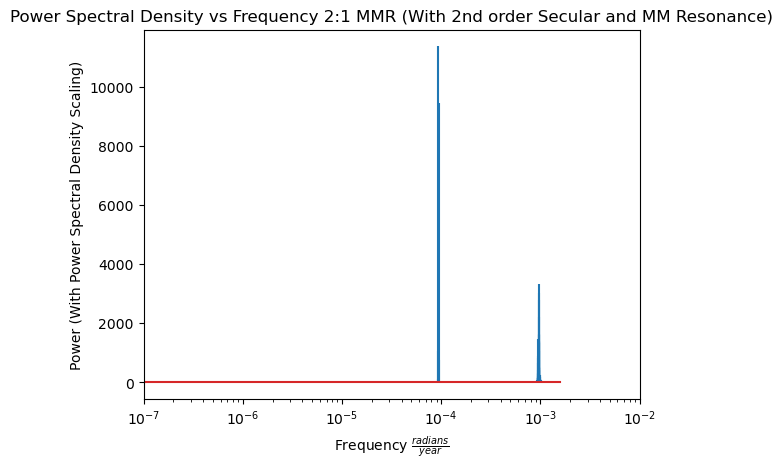

In [11]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)

for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    long_peri_j[i] = pham.state.particles[1].pomega
    e_j[i] = pham.state.particles[1].e
    print(times[i])

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency 2:1 MMR (With 2nd order Secular and MM Resonance)')
plt.show()

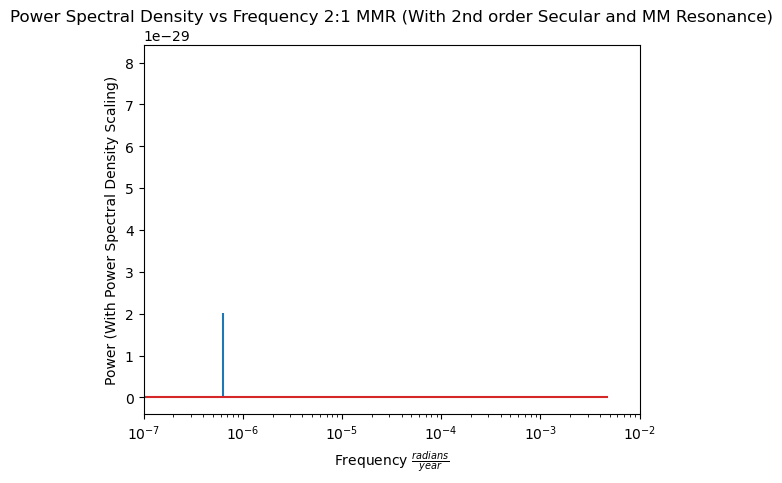

In [19]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(15e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))


pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)


for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    long_peri_j[i] = pham.state.particles[1].pomega
    e_j[i] = pham.state.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency 2:1 MMR (With 2nd order Secular and MM Resonance)')
plt.show()